In [1]:
library(SingleCellExperiment)
library(ggplot2)
library(BayesSpace)
library(Seurat)
library(cowplot)
library(RColorBrewer)
library(stringr)
library(Seurat)
library(SeuratDisk)

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: 'MatrixGenerics'


The following objects are masked from 'package:matrixStats':

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    rowCumsums, rowDiffs, rowIQRDiffs, rowIQRs, rowLogSumExps,
    rowMadDiffs, rowMads, rowMaxs, rowMeans2, rowMedians, rowMins,
    rowOrderStats, rowProds, rowQuantiles, rowRanges

In [2]:
#dir <- '/data/work/Ol_stem_new_lasso/Ol.seurat.integrated.RDS'
#sample <- 'tl4'
#log_method <- 'sct'
#clus <- 13

In [3]:
temp0 <- readRDS(dir)
temp0.list <- SplitObject(temp0,split.by="group")

Warning message:
"Not validating Seurat objects"
Warning message:
"Not validating Seurat objects"
Warning message:
"Not validating Seurat objects"
Warning message:
"Not validating Seurat objects"
Warning message:
"Not validating Seurat objects"
Warning message:
"Not validating Seurat objects"
Warning message:
"Not validating Seurat objects"
Warning message:
"Not validating Seurat objects"
Warning message:
"Not validating Seurat objects"
Warning message:
"Not validating Seurat objects"
Warning message:
"Not validating Seurat objects"
Warning message:
"Not validating Seurat objects"
Warning message:
"Not validating Seurat objects"
Warning message:
"Not validating Seurat objects"
Warning message:
"Not validating Seurat objects"
Warning message:
"Not validating Seurat objects"
Warning message:
"Not validating Seurat objects"
Warning message:
"Not validating Seurat objects"
Warning message:
"Not validating Seurat objects"
Warning message:
"Not validating Seurat objects"
Warning message:
"No

- what is qplot?
- 

In [ ]:
for(sample in unique(temp0$group)){
    seurat_spatialObj <- temp0.list[[sample]]
    set.seed(1234)
    seurat_spatialObj@meta.data$row = seurat_spatialObj@images[[paste0("image_",sample)]]@coordinates$x
    seurat_spatialObj@meta.data$col = seurat_spatialObj@images[[paste0("image_",sample)]]@coordinates$y

    # different normalization methods
    if(log_method=='log'){
        seurat_spatialObj <- NormalizeData(seurat_spatialObj)
        seurat_spatialObj <- FindVariableFeatures(seurat_spatialObj)
        seurat_spatialObj <- ScaleData(seurat_spatialObj)
        sce <- as.SingleCellExperiment(seurat_spatialObj)
        sce <- spatialPreprocess(sce, platform="ST", n.PCs=30, n.HVGs=3000, log.normalize=F)
    } else if(log_method=='sct'){
        #seurat_spatialObj=SCTransform(seurat_spatialObj, assay = "Spatial", verbose = FALSE)
        sce <- as.SingleCellExperiment(seurat_spatialObj,assay="SCT")
        sce <- spatialPreprocess(sce, platform="ST", n.PCs=30, n.HVGs=3000, log.normalize=F)
    }

    # determine the optimal number of clusters
    sce <- qTune(sce, qs=seq(2, 20), platform="ST", d=13)
    qPlot(sce)

    # fast version
    sce <- spatialCluster(sce, q=clus, platform="ST", d=8,
                        init.method="mclust", model="t", gamma=2,
                        nrep=3000, burn.in=100,
                        save.chain=TRUE)
    sce.seurat <- as.Seurat(sce,counts="counts",data="logcounts")
    Idents(sce.seurat) <- "spatial.cluster"
    locations <- seurat_spatialObj@images[[paste0("image_",sample)]]@coordinates[,c('x','y')]
    sce.seurat[['image']] <- new(Class = 'SlideSeq',assay = "Spatial",coordinates = locations)
    SaveH5Seurat(sce.seurat, filename = paste0(sample,".",log_method,".fast.h5Seurat"),assay="Spatial",overwrite=TRUE)
    Convert(paste0(sample,".",log_method,".fast.h5Seurat"), dest = "h5ad",overwrite=TRUE)
    
    # slow version
    sce <- spatialCluster(sce, q=clus, platform="ST", d=30,
                    init.method="mclust", model="t", gamma=2,
                    nrep=50000, burn.in=100,
                    save.chain=TRUE)
    sce.seurat <- as.Seurat(sce,counts="counts",data="logcounts")
    Idents(sce.seurat) <- "spatial.cluster"
    locations <- seurat_spatialObj@images[[paste0("image_",sample)]]@coordinates[,c('x','y')]
    sce.seurat[['image']] <- new(Class = 'SlideSeq',assay = "Spatial",coordinates = locations)
    SaveH5Seurat(sce.seurat, filename = paste0(sample,".",log_method,".fine.h5Seurat"),assay="Spatial",overwrite=TRUE)
    Convert(paste0(sample,".",log_method,".fine.h5Seurat"), dest = "h5ad",overwrite=TRUE)
}

### Log normalization or other normalization

Warning message in regularize.values(x, y, ties, missing(ties), na.rm = na.rm):
"collapsing to unique 'x' values"


### qPlot() plots the pseudo-log-likelihood as a function of q; we suggest choosing a q around the elbow of this plot.

Neighbors were identified for 0 out of 1073 spots.

Fitting model...

Fitting model...

Fitting model...

Fitting model...

Fitting model...

Fitting model...

Fitting model...

Fitting model...

Fitting model...

Fitting model...

Fitting model...

Fitting model...

Fitting model...

Fitting model...

Fitting model...

Fitting model...

Fitting model...

Fitting model...

Fitting model...



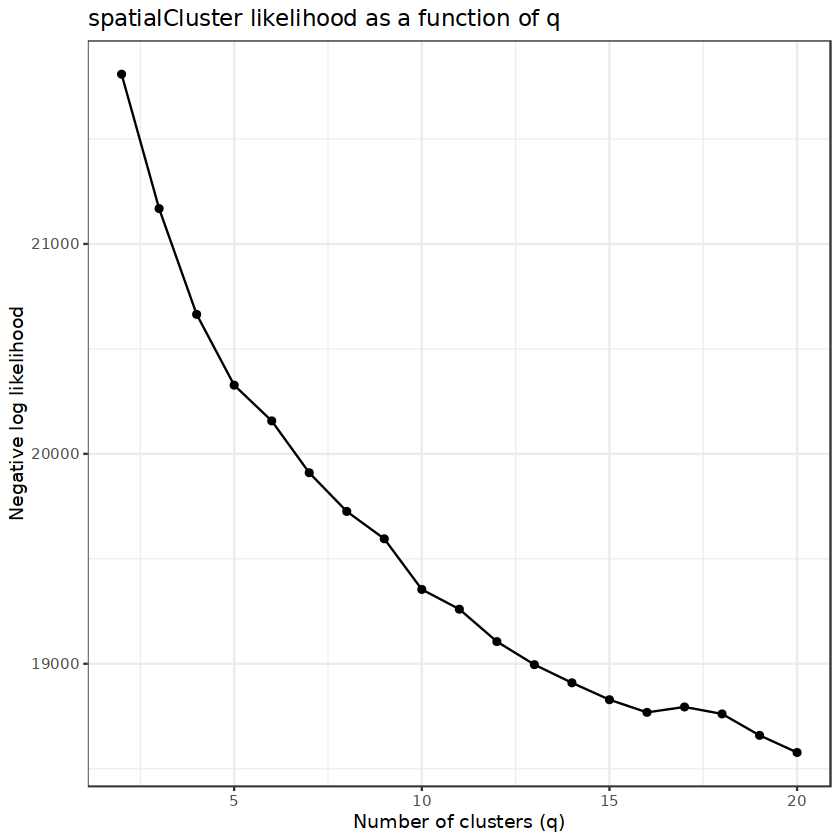

Neighbors were identified for 0 out of 1073 spots.

Fitting model...

Calculating labels using iterations 100 through 3000.



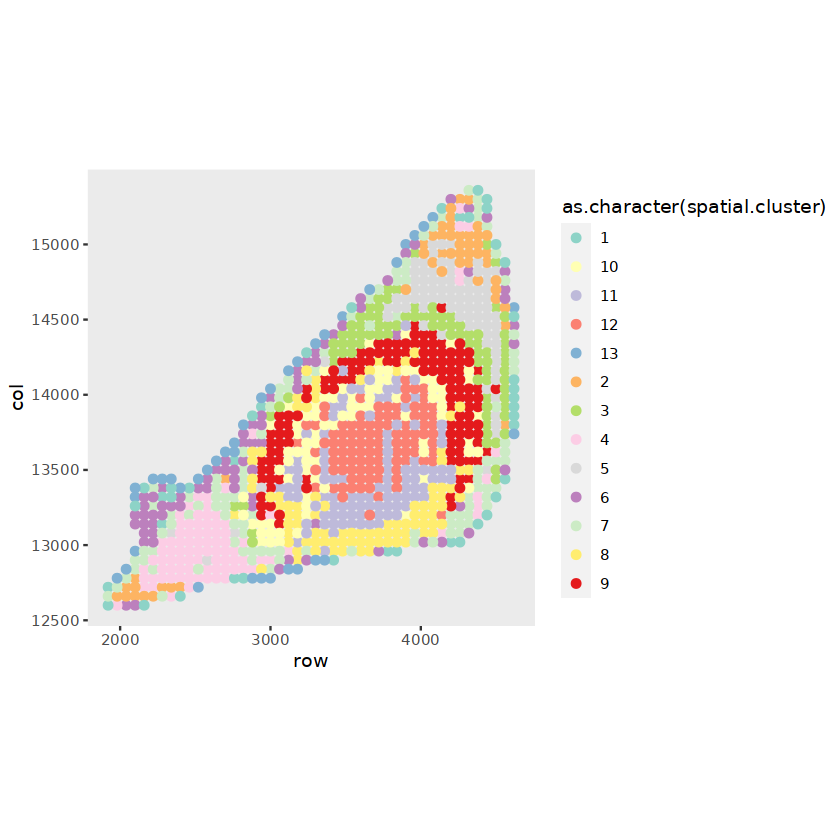

In [ ]:
#pale<-c(brewer.pal(12,"Set3"),brewer.pal(9,"Set1"),brewer.pal(8,"Dark2"),brewer.pal(12,"Paired"))
#temp <- as.data.frame(colData(sce))
#ggplot(temp) + geom_point(mapping=aes(x=row, y=col, colour = as.character(spatial.cluster)),size = 2)+
#        scale_colour_discrete(type=pale,na.value="grey")+
#        theme(panel.grid=element_blank())+
#        coord_fixed() 

Warning message:
"Keys should be one or more alphanumeric characters followed by an underscore, setting key from PC to PC_"
Warning message:
"Adding image data that isn't associated with any assays"
Creating h5Seurat file for version 3.1.5.9900

Adding counts for SCT

Adding data for SCT

No variable features found for SCT

Adding feature-level metadata for SCT

Adding cell embeddings for PCA

No loadings for PCA

No projected loadings for PCA

No standard deviations for PCA

No JackStraw data for PCA

Adding cell embeddings for UMAP.UNINTEGRATED

No loadings for UMAP.UNINTEGRATED

No projected loadings for UMAP.UNINTEGRATED

No standard deviations for UMAP.UNINTEGRATED

No JackStraw data for UMAP.UNINTEGRATED

Adding cell embeddings for HARMONY_PCA

No loadings for HARMONY_PCA

No projected loadings for HARMONY_PCA

No standard deviations for HARMONY_PCA

No JackStraw data for HARMONY_PCA

Adding cell embeddings for UMAP.HARMONY

No loadings for UMAP.HARMONY

No projected loadings for

Neighbors were identified for 0 out of 1073 spots.

Fitting model...



In [ ]:
#temp <- as.data.frame(colData(sce))
#ggplot(temp) + geom_point(mapping=aes(x=row, y=col, colour = as.character(spatial.cluster)),size = 2)+
#        scale_colour_discrete(type=pale,na.value="grey")+
#        theme(panel.grid=element_blank())+
#        coord_fixed() 